 implements a simple linear regression model to predict the logarithm of home sale prices (LOG_SALEPRICE) based on the year a home was built (YEARBUILT)

Simple Linear Regression
Intercept: -2.443668169752881
Coefficients: [0.00734377]
Mean Absolute Error: 0.26
Mean Squared Error: 0.12
R2 Score: 0.37


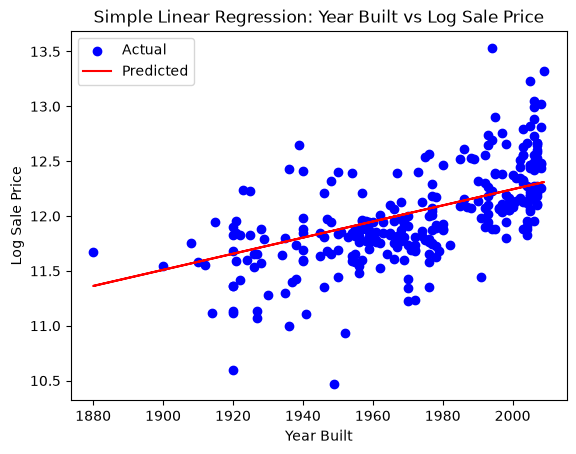

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# load home dataset
df = pd.read_csv("https://raw.githubusercontent.com/IBM/ml-learning-path-assets/master/data/predict_home_value.csv")
df = df.drop(['ID'], axis=1)

# appily log-transform the target (SALESPRICE) to increase stablitlity 
df['LOG_SALEPRICE'] = np.log(df['SALEPRICE'])

# isolate the feature 'YEARBUILT' as the independent variable and 'LOG_SALEPRICE' as the dependent variable
X = df[['YEARBUILT']]
y = df['LOG_SALEPRICE']

# Split the dataset into training (80%) and testing (20%) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train the model
model = LinearRegression()
model.fit(X_train, y_train)

# prediction regression line 
y_pred = model.predict(X_test)


#calculate and print performance metrics: Mean Absolute Error, Mean Squared Error, and R2 Score
print("Simple Linear Regression")
print(f"Intercept: {model.intercept_}")
print(f"Coefficients: {model.coef_}")
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

# graph the actual data points and the predicted regression line
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', label='Predicted')
plt.xlabel('Year Built')
plt.ylabel('Log Sale Price')
plt.title('Simple Linear Regression: Year Built vs Log Sale Price')
plt.legend()
plt.show()
